In [ ]:

import os
import sys
import random
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


os.environ["OPENCV_LOG_LEVEL"] = "ERROR"
warnings.filterwarnings('ignore')


!pip install timm onnx onnxscript -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import timm
from timm.loss import LabelSmoothingCrossEntropy

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

class PipelineConfig:
    """Centralized Hyperparameter & Path Orchestration Configuration."""
    BASE_DATA_DIR = "/kaggle/input/datasets/nirmalsankalana/crop-pest-and-disease-detection"
    
    CLASSES = [
        "Cashew anthracnose", "Cashew gumosis", "Cashew healthy", "Cashew leaf miner", "Cashew red rust",
        "Cassava bacterial blight", "Cassava brown spot", "Cassava green mite", "Cassava healthy", "Cassava mosaic",
        "Maize fall armyworm", "Maize grasshoper", "Maize healthy", "Maize leaf beetle", "Maize leaf blight", "Maize leaf spot", "Maize streak virus",
        "Tomato healthy", "Tomato leaf blight", "Tomato leaf curl", "Tomato septoria leaf spot", "Tomato verticulium wilt"
    ]
    
    SEED = 42
    IMAGE_SIZE = (256, 256)
    BATCH_SIZE = 32
    EPOCHS = 12                 
    EARLY_STOPPING_PATIENCE = 3 
    LR = 3e-4
    WEIGHT_DECAY = 1e-3         
    LABEL_SMOOTHING = 0.1       
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_WORKERS = 2             

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(PipelineConfig.SEED)
print(f"[SYSTEM CALIBRATION] Active Computing Hardware Architecture: {PipelineConfig.DEVICE}")

[SYSTEM CALIBRATION] Active Computing Hardware Architecture: cuda


In [ ]:


def execute_rigorous_data_sanitation(base_dir, classes):
    """
    Parses directories, applies decoding tests to filter corrupt records, 
    and returns a clean master dataset.
    """
    clean_records  = []
    corruption_log = []
    



    print("\n[STARTING AUDIT] Commencing complete dataset verification pass...")
    for class_idx, class_name in enumerate(classes):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            print(f" [MISSING PATH ERROR] Directory absent: {class_path}")
            continue
            


        for filename in os.listdir(class_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path  = os.path.join(class_path, filename)
                
                

                try:
                    

                    with Image.open(file_path) as img:
                        img.verify()
                    
                    
                    matrix_test = cv2.imread(file_path)
                    if matrix_test is None or matrix_test.size == 0:
                        raise ValueError("Decoded matrix contains no element arrays.")
                        
                      

                    crop_type = class_name.split()[0]
                    phenotype = " ".join(class_name.split()[1:])
                    
                    clean_records.append({
                        "file_path": file_path,
                        "class_name": class_name,
                        "label": class_idx,
                        "crop": crop_type,
                        "phenotype": phenotype,
                        "height": matrix_test.shape[0],
                        "width": matrix_test.shape[1]
                    })

                except Exception as error_context:
                    corruption_log.append({"file_path": file_path, "exception": str(error_context)})
                    


    df_clean = pd.DataFrame(clean_records)
    df_corrupt = pd.DataFrame(corruption_log)
    return df_clean, df_corrupt



df_master, df_corrupt_manifest = execute_rigorous_data_sanitation(PipelineConfig.BASE_DATA_DIR, PipelineConfig.CLASSES)



print(f"\n[AUDIT RESULTS COMPLETE]")
print(f" -> Structurally Sound Image Assets: {len(df_master)}")
print(f" -> Identified Corrupted Records Bypassed: {len(df_corrupt_manifest)}")


[STARTING AUDIT] Commencing complete dataset verification pass...


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: p


[AUDIT RESULTS COMPLETE]
 -> Structurally Sound Image Assets: 25170
 -> Identified Corrupted Records Bypassed: 50


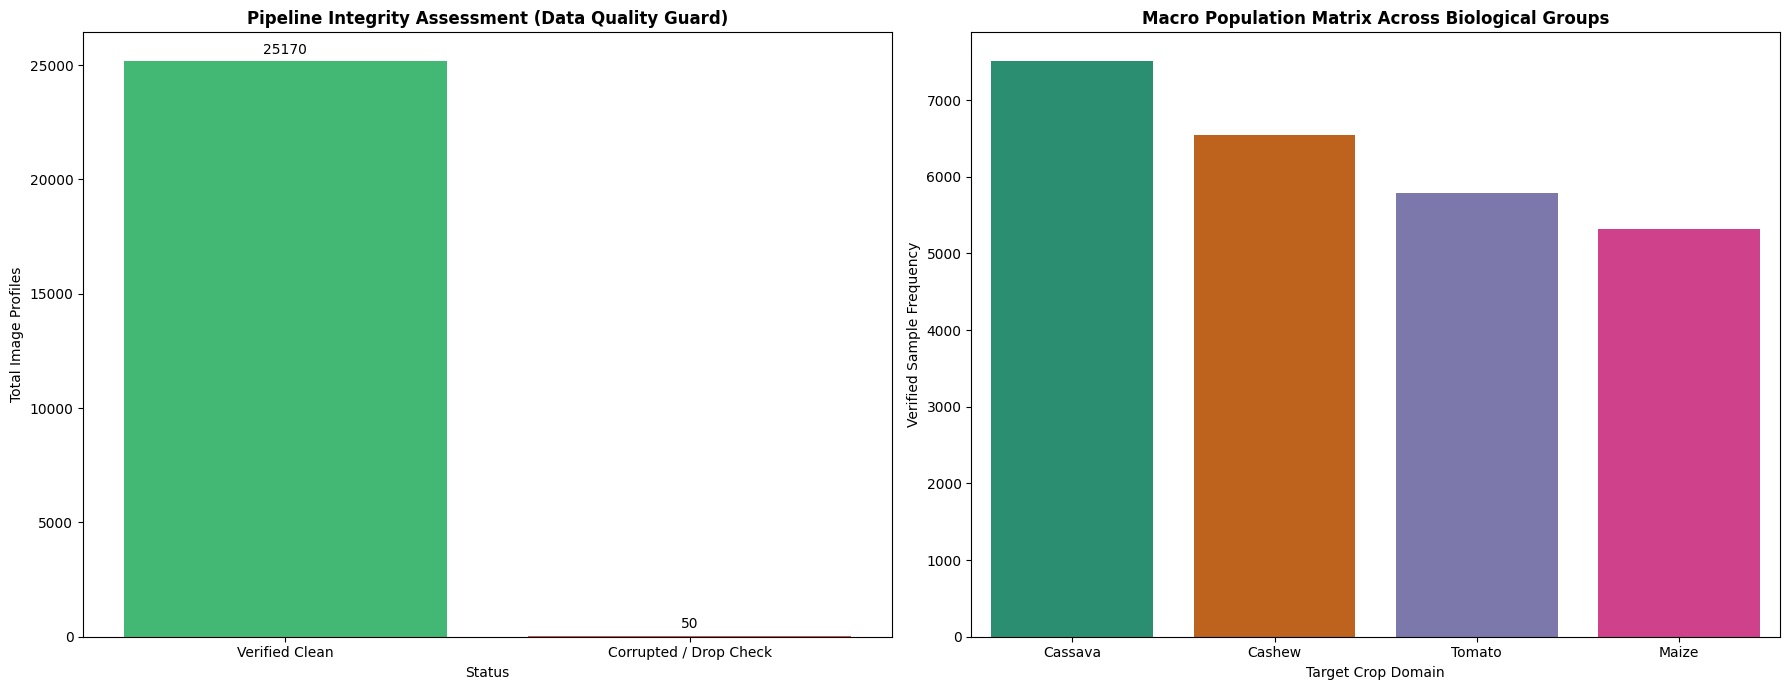

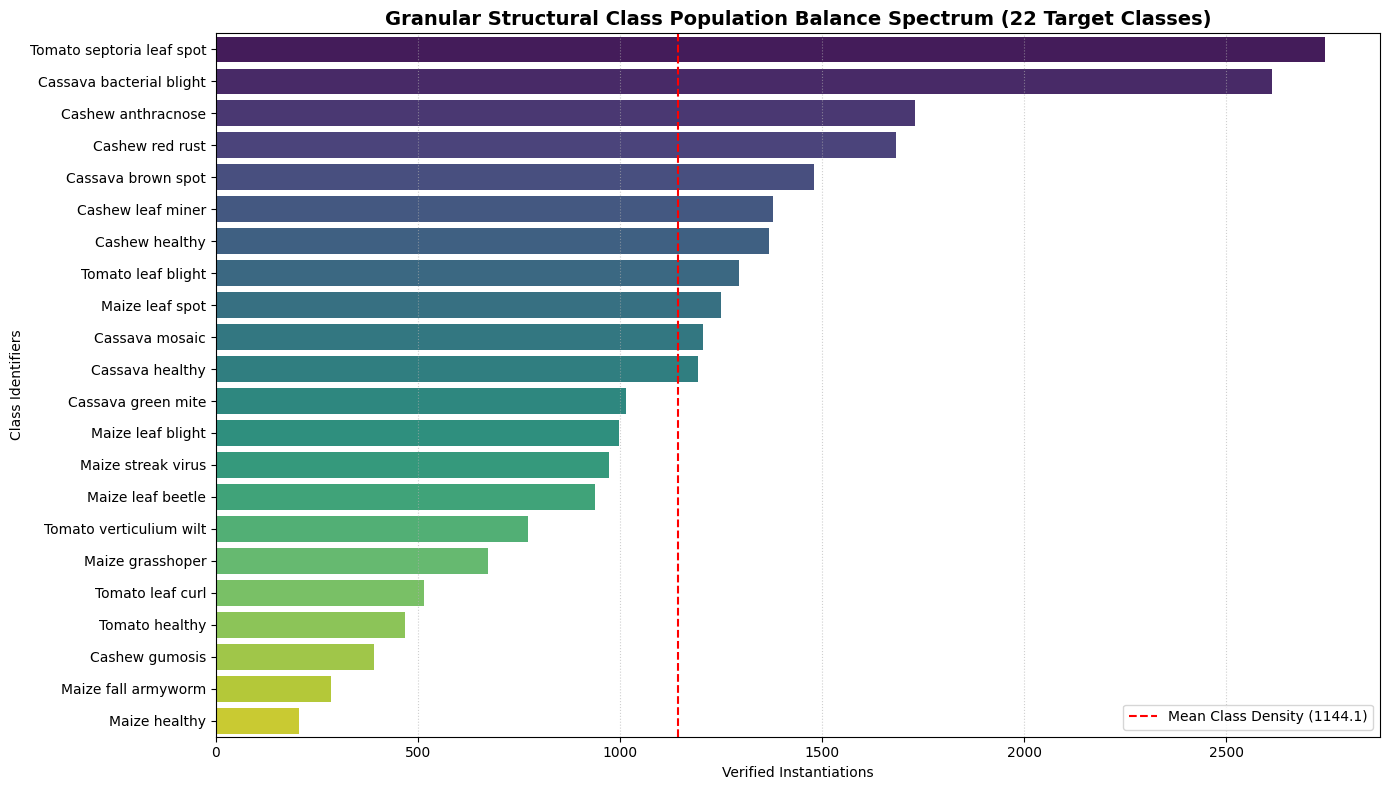

[SPLIT PROFILE] Data Split Strategy Matrix: Training Set: 20136 | Validation Set: 5034


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(18, 7))


health_data = pd.DataFrame({
    "Status": ["Verified Clean", "Corrupted / Drop Check"],
    "Count": [len(df_master), len(df_corrupt_manifest)]
})
sns.barplot(data=health_data, x="Status", y="Count", ax=axes[0], palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Pipeline Integrity Assessment (Data Quality Guard)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Total Image Profiles")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', label_type='edge', padding=3)



sns.countplot(data=df_master, x='crop', ax=axes[1], order=df_master['crop'].value_counts().index, palette='Dark2')
axes[1].set_title("Macro Population Matrix Across Biological Groups", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Target Crop Domain")
axes[1].set_ylabel("Verified Sample Frequency")
plt.tight_layout()
plt.show()



plt.figure(figsize=(14, 8))
sns.countplot(data=df_master, y='class_name', order=df_master['class_name'].value_counts().index, palette='viridis')
plt.axvline(df_master['class_name'].value_counts().mean(), color='red', linestyle='--', label=f"Mean Class Density ({df_master['class_name'].value_counts().mean():.1f})")
plt.title("Granular Structural Class Population Balance Spectrum (22 Target Classes)", fontsize=14, fontweight='bold')
plt.xlabel("Verified Instantiations")
plt.ylabel("Class Identifiers")
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()




train_df, val_df = train_test_split(
    df_master, 
    test_size=0.20, 
    stratify=df_master['label'], 
    random_state=PipelineConfig.SEED
)
print(f"[SPLIT PROFILE] Data Split Strategy Matrix: Training Set: {len(train_df)} | Validation Set: {len(val_df)}")

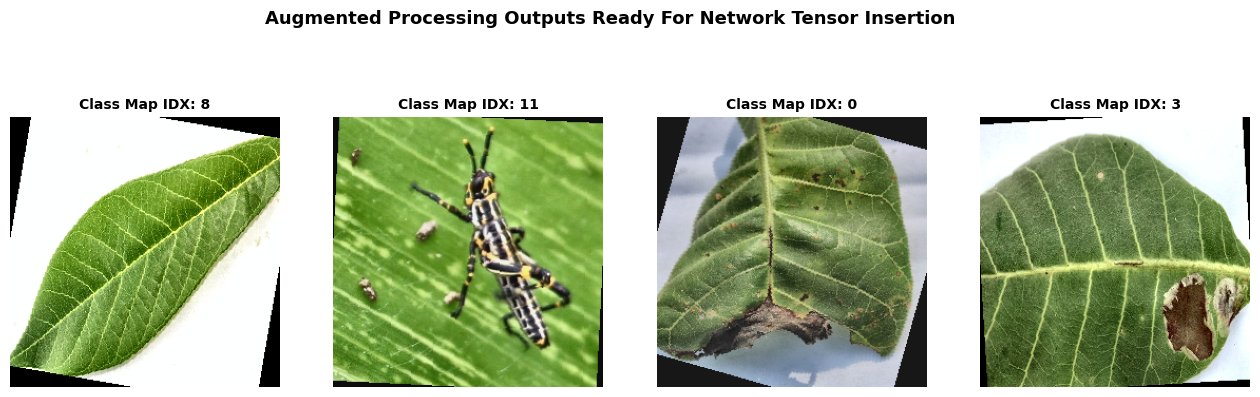

In [ ]:



class AgTechProductionDataset(Dataset):
    """High-Throughput Image Processing Engine with Embedded OpenCV Image Processing."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
 
 
        self.clahe_engine = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))



    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = row['file_path']
        label = int(row['label'])
        
     
     
        image = cv2.imread(file_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
      
      
        ycrcb_array = cv2.cvtColor(image, cv2.COLOR_RGB2YCrCb)
        channels = list(cv2.split(ycrcb_array))
        channels[0] = self.clahe_engine.apply(channels[0])  
        ycrcb_array = cv2.merge(channels)
        image = cv2.cvtColor(ycrcb_array, cv2.COLOR_YCrCb2RGB)
        
        
        
        image = cv2.resize(image, PipelineConfig.IMAGE_SIZE, interpolation=cv2.INTER_CUBIC)
        


        if self.transform:
            image = self.transform(image)
            
        return image, label



train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])





train_dataset = AgTechProductionDataset(train_df, transform=train_transforms)
val_dataset   = AgTechProductionDataset(val_df, transform=val_transforms)


train_loader = DataLoader(train_dataset, batch_size=PipelineConfig.BATCH_SIZE, shuffle=True, num_workers=PipelineConfig.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=PipelineConfig.BATCH_SIZE, shuffle=False, num_workers=PipelineConfig.NUM_WORKERS, pin_memory=True)



preview_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
images_batch, labels_batch = next(iter(preview_loader))



fig, axes   = plt.subplots(1, 4, figsize=(16,  5))

for idx in range(4):
    sample_tensor = images_batch[idx].numpy().transpose((1, 2, 0))
    
    
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    sample_tensor  = std *  sample_tensor +  mean
    sample_tensor  = np.clip(sample_tensor,  0, 1)
    
    
    axes[idx].imshow(sample_tensor)
    axes[idx].set_title(f"Class Map IDX: {labels_batch[idx].item()}", fontsize=10, fontweight='bold')
    axes[idx].axis('off')
plt.suptitle("Augmented Processing Outputs Ready For Network Tensor Insertion", fontsize=13, fontweight='bold')
plt.show()

In [ ]:

class EarlyStoppingTracker:

    def __init__(self, patience=3, delta=1e-4):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop_flag = False




    def check_status(self, validation_loss):
        if validation_loss < self.best_loss - self.delta:
            self.best_loss = validation_loss
            self.counter = 0  
            is_improved = True

        else:
            self.counter += 1
            is_improved = False
            print(f" -> Overfitting Alert: EarlyStopping Monitor [ {self.counter} / {self.patience} ]")
            if self.counter >= self.patience:
                self.early_stop_flag = True
        return is_improved

class CropProtectionModelFactory(nn.Module):

    def __init__(self, model_name, num_classes=22, pretrained=True):
        super().__init__()
        self.model_name = model_name
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
        

        
    def forward(self, x):
        return self.backbone(x)

In [ ]:

def execute_training_pipeline(model, train_gen, val_gen, config):
    model.to(config.DEVICE)
    
    
    criterion  = LabelSmoothingCrossEntropy(smoothing=config.LABEL_SMOOTHING)
     


    optimizer  = optim.AdamW(model.parameters(), lr=config.LR, weight_decay=config.WEIGHT_DECAY)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
    tracker    = EarlyStoppingTracker(patience=config.EARLY_STOPPING_PATIENCE)
    
    metrics_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(config.EPOCHS):
        
        model.train()
        running_loss = 0.0
        for images, labels in train_gen:
            images, labels = images.to(config.DEVICE), labels.to(config.DEVICE)
            


            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            



            running_loss += loss.item()  * images.size(0)
            
        epoch_train_loss  = running_loss / len(train_gen.dataset)
        
        
        model.eval()
        running_val_loss    = 0.0
        correct_predictions = 0
        



        with torch.no_grad():
            for images, labels in val_gen:
                images, labels = images.to(config.DEVICE), labels.to(config.DEVICE)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                

                running_val_loss += loss.item() * images.size(0)
                _, predictions = torch.max(outputs, 1)
                correct_predictions += torch.sum(predictions == labels.data)
                
        epoch_val_loss = running_val_loss / len(val_gen.dataset)
        epoch_val_acc  = correct_predictions.double().item() / len(val_gen.dataset)
        
        scheduler.step(epoch_val_loss)
        
        metrics_history['train_loss'].append(epoch_train_loss)
        metrics_history['val_loss'].append(epoch_val_loss)
        metrics_history['val_acc'].append(epoch_val_acc)
        
        print(f"Epoch [ {epoch+1} / {config.EPOCHS} ] -> Train Loss: {epoch_train_loss:.4f} | Validation Loss: {epoch_val_loss:.4f} | Val Accuracy: {epoch_val_acc:.4f}")
        
       
        checkpoint_flag = tracker.check_status(epoch_val_loss)
        if checkpoint_flag:
            torch.save(model.state_dict(), f"best_weights_{model.model_name}.pth")
            print(f"  ==> Saved Champion Model Weights: best_weights_{model.model_name}.pth")
            




        if tracker.early_stop_flag:
            print(f"[HALTING CRITERIA REACHED] Terminating optimization pass to protect against generalization degradation.")
            break
            
    return metrics_history

 
target_architectures  = ['efficientnet_b0',  'resnet34']
experimental_registry = {}





for model_name in target_architectures:
    print(f"\n" + "="*50)
    print(f"INITIALIZING EXPERIMENTATION SEQUENCE: {model_name.upper()}")
    print("="*50)
    



    
    instantiated_model = CropProtectionModelFactory(model_name=model_name, num_classes=22)
    history_log = execute_training_pipeline(instantiated_model, train_loader, val_loader, PipelineConfig)
    experimental_registry[model_name] = history_log


INITIALIZING EXPERIMENTATION SEQUENCE: EFFICIENTNET_B0


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: p

Epoch [ 1 / 12 ] -> Train Loss: 1.2041 | Validation Loss: 0.9577 | Val Accuracy: 0.8725
  ==> Saved Champion Model Weights: best_weights_efficientnet_b0.pth


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: p

...

Epoch [ 10 / 12 ] -> Train Loss: 0.7549 | Validation Loss: 0.8453 | Val Accuracy: 0.9056
  ==> Saved Champion Model Weights: best_weights_resnet34.pth


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: p

Epoch [ 11 / 12 ] -> Train Loss: 0.7408 | Validation Loss: 0.8282 | Val Accuracy: 0.9112
  ==> Saved Champion Model Weights: best_weights_resnet34.pth


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: p

Epoch [ 12 / 12 ] -> Train Loss: 0.7322 | Validation Loss: 0.8381 | Val Accuracy: 0.9080
 -> Overfitting Alert: EarlyStopping Monitor [ 1 / 3 ]


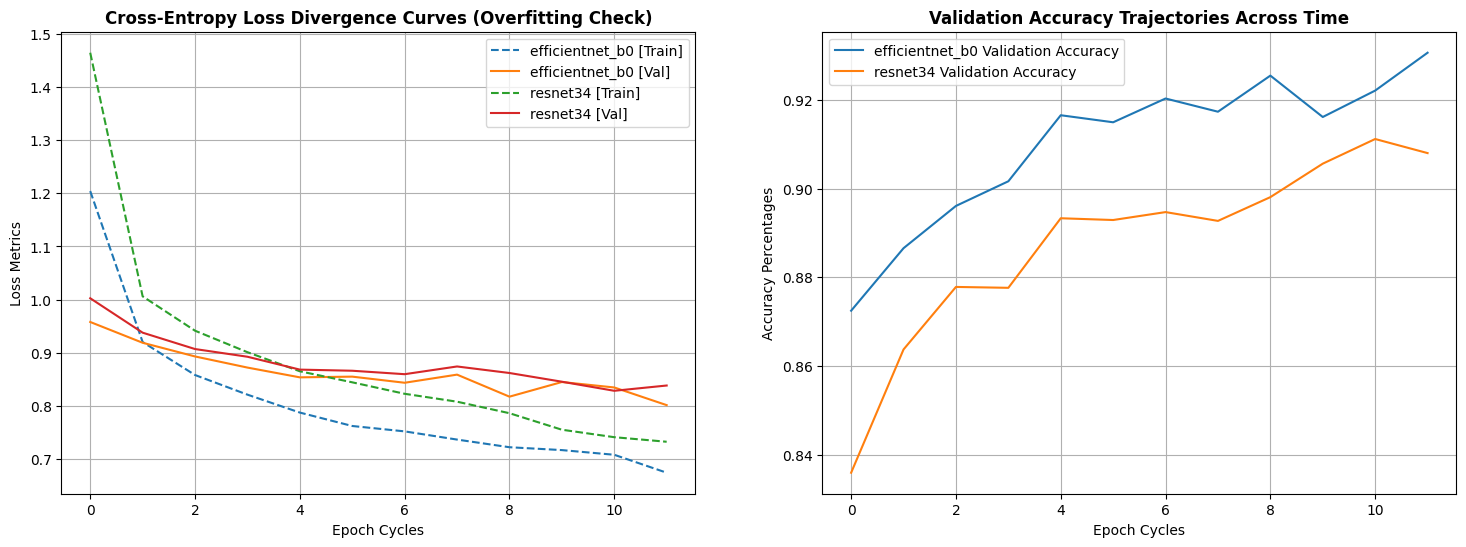

Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment



=== EXPERIMENTAL ANALYSIS REPORT MATRIX ===


,Target Phenotype Variant,Precision Matrix,Recall Matrix,F1-Score ($F_1$)
1,Cashew gumosis,0.987342,1.000000,0.993631
13,Maize leaf beetle,1.000000,0.984043,0.991957
4,Cashew red rust,0.985251,0.994048,0.989630
11,Maize grasshoper,0.992537,0.985185,0.988848
2,Cashew healthy,0.981884,0.989051,0.985455
9,Cassava mosaic,0.971545,0.991701,0.981520
8,Cassava healthy,0.967213,0.991597,0.979253
3,Cashew leaf miner,0.970696,0.963636,0.967153
0,Cashew anthracnose,0.965015,0.956647,0.960813
5,Cassava bacterial blight,0.948669,0.954111,0.951382


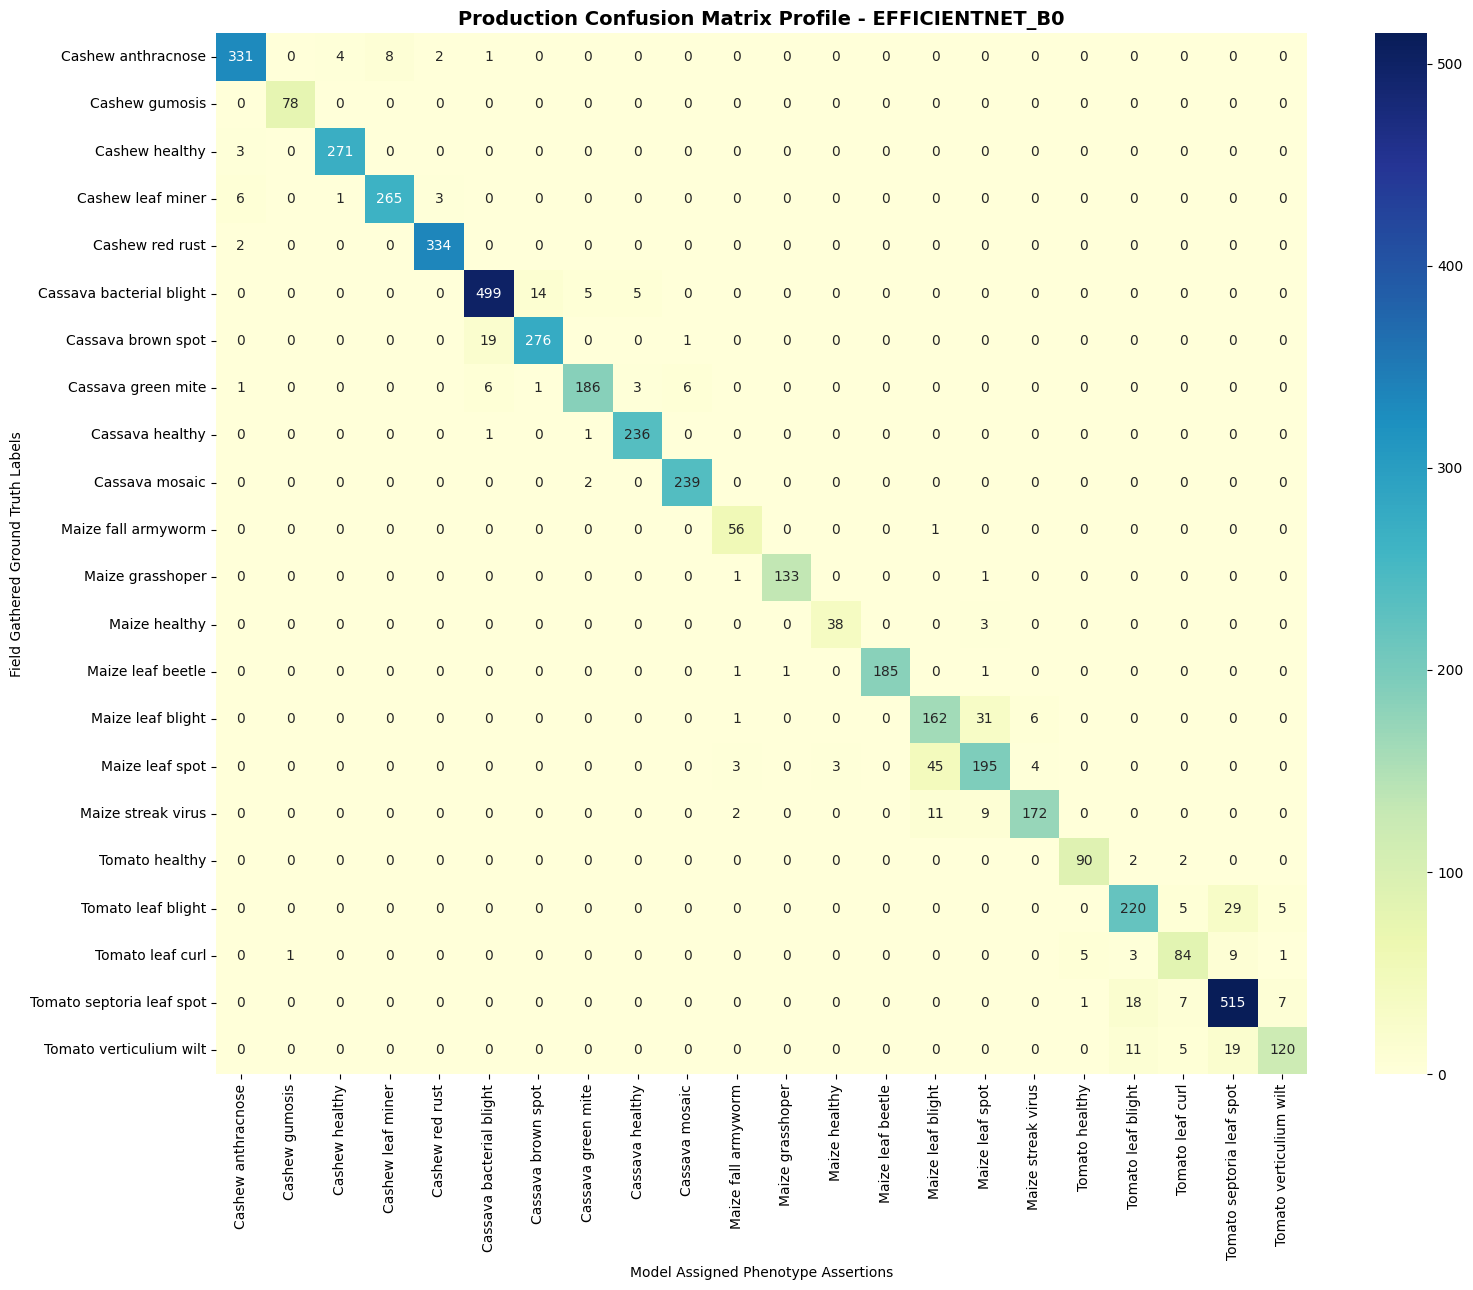

In [ ]:

fig, axes   = plt.subplots(1,  2, figsize=(18, 6))



for model_name in target_architectures:
    axes[0].plot(experimental_registry[model_name]['train_loss'],linestyle='--',  label =f"{model_name} [Train]")
    axes[0].plot(experimental_registry[model_name]['val_loss'],  linestyle='-', label= f"{model_name} [Val]")
axes[0].set_title("Cross-Entropy Loss Divergence Curves (Overfitting Check)",  fontsize=12,fontweight ='bold')
axes[0].set_xlabel("Epoch Cycles")
axes[0].set_ylabel("Loss Metrics")
axes[0].legend()
axes[0].grid(True)



for model_name in target_architectures:
    axes[1].plot(experimental_registry[model_name]['val_acc'], label = f"{model_name} Validation Accuracy")
axes[1].set_title("Validation Accuracy Trajectories Across Time", fontsize = 12, fontweight = 'bold')
axes[1].set_xlabel("Epoch Cycles")

axes[1].set_ylabel("Accuracy Percentages")
axes[1].legend()
axes[1].grid(True)

plt.show()


champion_architecture  = 'efficientnet_b0'
eval_engine   =  CropProtectionModelFactory(model_name=champion_architecture, num_classes=22)
eval_engine.load_state_dict(torch.load(f"best_weights_{champion_architecture}.pth"))
eval_engine.to(PipelineConfig.DEVICE)
eval_engine.eval()

ground_truth_list      = []
prediction_logits_list = []





with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(PipelineConfig.DEVICE)
        outputs = eval_engine(images)
        _, predictions = torch.max(outputs, 1)
        
        prediction_logits_list.extend(predictions.cpu().numpy())
        ground_truth_list.extend(labels.numpy())




precision, recall, f1, _  = precision_recall_fscore_support(ground_truth_list,  prediction_logits_list,average= None)
df_analytics = pd.DataFrame({
    "Target Phenotype Variant": PipelineConfig.CLASSES,
    "Precision Matrix": precision,
    "Recall Matrix": recall,
    "F1-Score ($F_1$)": f1
}).sort_values(by="F1-Score ($F_1$)", ascending=False)



print("\n=== EXPERIMENTAL ANALYSIS REPORT MATRIX ===")
display(df_analytics)




cm_matrix = confusion_matrix(ground_truth_list, prediction_logits_list)
plt.figure(figsize=(16, 13))
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu', xticklabels=PipelineConfig.CLASSES, yticklabels=PipelineConfig.CLASSES)
plt.title(f"Production Confusion Matrix Profile - {champion_architecture.upper()}", fontsize=14, fontweight='bold')
plt.xlabel("Model Assigned Phenotype Assertions")
plt.ylabel("Field Gathered Ground Truth Labels")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:

def compile_to_onnx_runtime_format(model_name, weight_path, target_output_name):
    """
    Translates PyTorch computation layouts into optimized ONNX graph formats 
    for low-latency OpenCV inference.
    """
    production_model  =  CropProtectionModelFactory(model_name=model_name,  num_classes= 22)
    production_model.load_state_dict(torch.load(weight_path, map_location='cpu'))
    production_model.eval()
    
     
    dummy_input_tensor =  torch.randn(1,3, PipelineConfig.IMAGE_SIZE[0], PipelineConfig.IMAGE_SIZE[1])
    



    print(f"\n[ONNX SYSTEM COMPILATION] Serializing computation graph for: {model_name}...")
    torch.onnx.export(
        production_model,
        dummy_input_tensor,
        target_output_name,
        export_params=True,
        opset_version=12,          # Standard, stable compatibility layer version for OpenCV DNN
        do_constant_folding=True,   # Optimizes operations by pre-calculating constant folds
        input_names=['input_tensor'],
        output_names=['output_logits'],
        dynamic_axes={
            'input_tensor': {0: 'batch_size'}, 
            'output_logits': {0: 'batch_size'}
        }                          
    )
    print(f" [COMPILATION SUCCESSFUL] Target binary written to local disk space: {target_output_name}")




for model_name in target_architectures:
    compile_to_onnx_runtime_format(
        model_name=model_name,
        weight_path=f"best_weights_{model_name}.pth",
        target_output_name=f"crop_protection_{model_name}.onnx"
    )




print("\n" + "="*60)
print("ALL PIPELINE SYSTEMS NOMINAL: RUNTIME BINARIES READY FOR PRODUCTION")
print("="*60)


[ONNX SYSTEM COMPILATION] Serializing computation graph for: efficientnet_b0...


W0607 19:52:14.716000 58 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0607 19:52:15.784000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0607 19:52:15.785000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int

[torch.onnx] Obtain model graph for `CropProtectionModelFactory([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CropProtectionModelFactory([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 12).
Failed to convert the model to the target version 12 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Translate the graph into ONNX... ✅
 [COMPILATION SUCCESSFUL] Target binary written to local disk space: crop_protection_efficientnet_b0.onnx


...


[ONNX SYSTEM COMPILATION] Serializing computation graph for: resnet34...


W0607 19:52:23.783000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0607 19:52:23.784000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0607 19:52:23.787000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0607 19:52:23.788000 58 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `CropProtectionModelFactory([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CropProtectionModelFactory([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 12).
Failed to convert the model to the target version 12 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
 [COMPILATION SUCCESSFUL] Target binary written to local disk space: crop_protection_resnet34.onnx

ALL PIPELINE SYSTEMS NOMINAL: RUNTIME BINARIES READY FOR PRODUCTION


In [15]:
import os
print("Files currently on disk:", os.listdir('.'))

Files currently on disk: ['crop_protection_efficientnet_b0.onnx.data', 'crop_protection_efficientnet_b0.onnx', 'crop_protection_resnet34.onnx', '.virtual_documents', 'crop_protection_resnet34.onnx.data', 'best_weights_efficientnet_b0.pth', 'best_weights_resnet34.pth']
